This is to explore Long Short-Term Memory (LSTM) networks, a type of recurrent neural network (RNN), be use for stock price prediction

In [6]:
#
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

#import os
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error

import yfinance as yf

In [7]:
import warnings
warnings.filterwarnings("ignore")

In [8]:
# Data source from yfinance as below
#   tentatively retreive 3 years stock data

company = "^HSI"
df_HKstock = yf.download(company, start="2023-01-01", end="2026-01-01",
                    auto_adjust=True ).droplevel('Ticker', axis=1)
df_HKstock

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2023-01-03,20145.289062,20212.550781,19303.730469,19570.429688,2286700000
2023-01-04,20793.109375,20793.109375,20233.390625,20319.980469,3016000000
2023-01-05,21052.169922,21396.089844,20962.400391,21295.869141,2875400000
2023-01-06,20991.640625,21282.710938,20862.769531,21220.890625,2754500000
2023-01-09,21388.339844,21470.689453,21216.919922,21295.939453,2697900000
...,...,...,...,...,...
2025-12-23,25774.140625,25927.660156,25726.449219,25875.849609,2240900000
2025-12-24,25818.929688,25890.869141,25772.869141,25780.089844,1236300000
2025-12-29,25635.230469,26082.939453,25630.750000,25928.890625,2931600000


In [9]:
# Save copy to CSV
df_HKstock.to_csv('test.HK260101.csv')

In [10]:
#
df_source = pd.read_csv("test.HK260101.csv")
df_source

,Date,Close,High,Low,Open,Volume
0,2023-01-03,20145.289062,20212.550781,19303.730469,19570.429688,2286700000
1,2023-01-04,20793.109375,20793.109375,20233.390625,20319.980469,3016000000
2,2023-01-05,21052.169922,21396.089844,20962.400391,21295.869141,2875400000
3,2023-01-06,20991.640625,21282.710938,20862.769531,21220.890625,2754500000
4,2023-01-09,21388.339844,21470.689453,21216.919922,21295.939453,2697900000
...,...,...,...,...,...,...
730,2025-12-23,25774.140625,25927.660156,25726.449219,25875.849609,2240900000
731,2025-12-24,25818.929688,25890.869141,25772.869141,25780.089844,1236300000
732,2025-12-29,25635.230469,26082.939453,25630.750000,25928.890625,2931600000
733,2025-12-30,25854.599609,25930.220703,25611.230469,25636.400391,3138100000


In [11]:
# Set Date
df_source["Date"] = pd.to_datetime(df_source["Date"], format="%Y-%m-%d")
df_source

,Date,Close,High,Low,Open,Volume
0,2023-01-03,20145.289062,20212.550781,19303.730469,19570.429688,2286700000
1,2023-01-04,20793.109375,20793.109375,20233.390625,20319.980469,3016000000
2,2023-01-05,21052.169922,21396.089844,20962.400391,21295.869141,2875400000
3,2023-01-06,20991.640625,21282.710938,20862.769531,21220.890625,2754500000
4,2023-01-09,21388.339844,21470.689453,21216.919922,21295.939453,2697900000
...,...,...,...,...,...,...
730,2025-12-23,25774.140625,25927.660156,25726.449219,25875.849609,2240900000
731,2025-12-24,25818.929688,25890.869141,25772.869141,25780.089844,1236300000
732,2025-12-29,25635.230469,26082.939453,25630.750000,25928.890625,2931600000
733,2025-12-30,25854.599609,25930.220703,25611.230469,25636.400391,3138100000


In [12]:
df_source.info()

<class 'pandas.DataFrame'>
RangeIndex: 735 entries, 0 to 734
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    735 non-null    datetime64[us]
 1   Close   735 non-null    float64       
 2   High    735 non-null    float64       
 3   Low     735 non-null    float64       
 4   Open    735 non-null    float64       
 5   Volume  735 non-null    int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 34.6 KB


In [13]:
# Set Date as index - time series data
df_source = df_source.set_index('Date', ) 
df_source.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 735 entries, 2023-01-03 to 2025-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   735 non-null    float64
 1   High    735 non-null    float64
 2   Low     735 non-null    float64
 3   Open    735 non-null    float64
 4   Volume  735 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 34.5 KB


In [14]:
df = df_source
df

,Close,High,Low,Open,Volume
Date,,,,,
2023-01-03,20145.289062,20212.550781,19303.730469,19570.429688,2286700000
2023-01-04,20793.109375,20793.109375,20233.390625,20319.980469,3016000000
2023-01-05,21052.169922,21396.089844,20962.400391,21295.869141,2875400000
2023-01-06,20991.640625,21282.710938,20862.769531,21220.890625,2754500000
2023-01-09,21388.339844,21470.689453,21216.919922,21295.939453,2697900000
...,...,...,...,...,...
2025-12-23,25774.140625,25927.660156,25726.449219,25875.849609,2240900000
2025-12-24,25818.929688,25890.869141,25772.869141,25780.089844,1236300000
2025-12-29,25635.230469,26082.939453,25630.750000,25928.890625,2931600000


In [15]:
# Data pre-processing
df.isnull().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [16]:
# This is preserve as for handling missing values, if applicable
df.bfill()

,Close,High,Low,Open,Volume
Date,,,,,
2023-01-03,20145.289062,20212.550781,19303.730469,19570.429688,2286700000
2023-01-04,20793.109375,20793.109375,20233.390625,20319.980469,3016000000
2023-01-05,21052.169922,21396.089844,20962.400391,21295.869141,2875400000
2023-01-06,20991.640625,21282.710938,20862.769531,21220.890625,2754500000
2023-01-09,21388.339844,21470.689453,21216.919922,21295.939453,2697900000
...,...,...,...,...,...
2025-12-23,25774.140625,25927.660156,25726.449219,25875.849609,2240900000
2025-12-24,25818.929688,25890.869141,25772.869141,25780.089844,1236300000
2025-12-29,25635.230469,26082.939453,25630.750000,25928.890625,2931600000


In [17]:
# Calculate moving averages and daily returns

df['20-day MA'] = df['Close'].rolling(window=20).mean()
df['50-day MA'] = df['Close'].rolling(window=50).mean()
df['Daily Return'] = df['Close'].pct_change()

In [18]:
# To check NaN
df[df.isna().values==True].drop_duplicates()

,Close,High,Low,Open,Volume,20-day MA,50-day MA,Daily Return
Date,,,,,,,,
2023-01-03,20145.289062,20212.550781,19303.730469,19570.429688,2286700000,NaN,NaN,NaN
2023-01-04,20793.109375,20793.109375,20233.390625,20319.980469,3016000000,NaN,NaN,0.032157
2023-01-05,21052.169922,21396.089844,20962.400391,21295.869141,2875400000,NaN,NaN,0.012459
2023-01-06,20991.640625,21282.710938,20862.769531,21220.890625,2754500000,NaN,NaN,-0.002875
2023-01-09,21388.339844,21470.689453,21216.919922,21295.939453,2697900000,NaN,NaN,0.018898
2023-01-10,21331.460938,21395.419922,21187.730469,21370.419922,2543200000,NaN,NaN,-0.002659
2023-01-11,21436.050781,21686.300781,21327.410156,21463.820312,2971300000,NaN,NaN,0.004903
2023-01-12,21514.099609,21698.939453,21223.839844,21599.820312,2834600000,NaN,NaN,0.003641
2023-01-13,21738.660156,21770.080078,21474.980469,21605.070312,2463600000,NaN,NaN,0.010438


In [19]:
df = df.dropna()   # Drop all NaN
df

,Close,High,Low,Open,Volume,20-day MA,50-day MA,Daily Return
Date,,,,,,,,
2023-03-16,19203.910156,19388.769531,19109.070312,19197.970703,3047400000,20119.497070,20940.693633,-0.017194
2023-03-17,19518.589844,19597.179688,19303.289062,19439.839844,4332300000,20059.436035,20928.159648,0.016386
2023-03-20,19000.710938,19382.970703,18829.109375,19352.900391,2839000000,19965.123535,20892.311680,-0.026533
2023-03-21,19258.759766,19295.640625,19018.099609,19118.869141,1929700000,19901.587012,20856.443477,0.013581
2023-03-22,19591.429688,19775.689453,19428.359375,19428.359375,2364100000,19859.966504,20828.439258,0.017274
...,...,...,...,...,...,...,...,...
2025-12-23,25774.140625,25927.660156,25726.449219,25875.849609,2240900000,25749.411523,25954.808828,-0.001071
2025-12-24,25818.929688,25890.869141,25772.869141,25780.089844,1236300000,25743.954004,25962.360430,0.001738
2025-12-29,25635.230469,26082.939453,25630.750000,25928.890625,2931600000,25728.419043,25956.853047,-0.007115


In [20]:
# Configuration

# For ~ 80:20 Split
test_days = 135

# choose the number of days on which to base our predictions 
nb_days = 60

# Number of days into the future we want to predict
n_steps_out = 10

#
epochsMS=50 
batch_sizeMS = 50
epochs2=30 
batch_size2 = 32

In [21]:
# For normailized Data

# from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))  
scaled_data = scaler.fit_transform(df['Close'].values.reshape(-1,1))

In [22]:
# ADF Test : p-value < 0.05 for stationary data

#from statsmodels.tsa.stattools import adfuller

close_series = df['Close']
def check_stationarity(series):
    result = adfuller(series.dropna())  # Drop NaN values if any
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    if result[1] < 0.05:
        print("The series is stationary.")
    else:
        print("The series is not stationary.")

check_stationarity(close_series)

ADF Statistic: -0.7493101898602278
p-value: 0.8335604682308543
The series is not stationary.


# To transform time series stationary...
There are three major time series patterns: trend, seasonality, and cycles. Trend and cycles are usually combined into a single component, with a trend-cycle component, a seasonal component, and a remainder component (containing the rest of the time series).

To make time series stationary, the principle is to estimate trend and seasonality, and to remove those from the time series. Then to apply the forecasting technique (i.e here LSTM), the final step being to convert the forcasted values into the original scale by adding the estimated trend and seasonality.

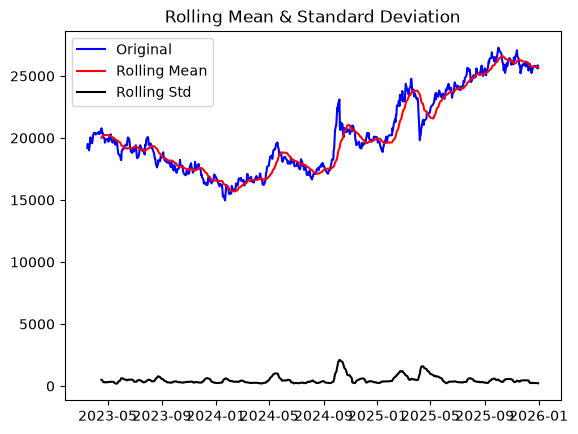

Results of Dickey-Fuller Test:
Test Statistic                  -0.749310
p-value                          0.833560
#Lags Used                       0.000000
Number of Observations Used    685.000000
Critical Value (1%)             -3.439932
Critical Value (5%)             -2.865769
Critical Value (10%)            -2.569022
dtype: float64


In [23]:
#... The following cells are use for model(s), such as LSTM in transformation
#... test stationarity with DFT

close_series = df['Close']
def test_stationarity(timeseries):
    '''
    Input: timeseries (dataframe): timeseries for which we want to study the stationarity
    '''
    
    #Determing rolling statistics
    rolmean = timeseries.rolling(20).mean()
    rolstd = timeseries.rolling(20).std()

    #Plot rolling statistics:
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)

    #Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value',\
                                             '#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

test_stationarity(close_series)

<Figure size 640x480 with 0 Axes>

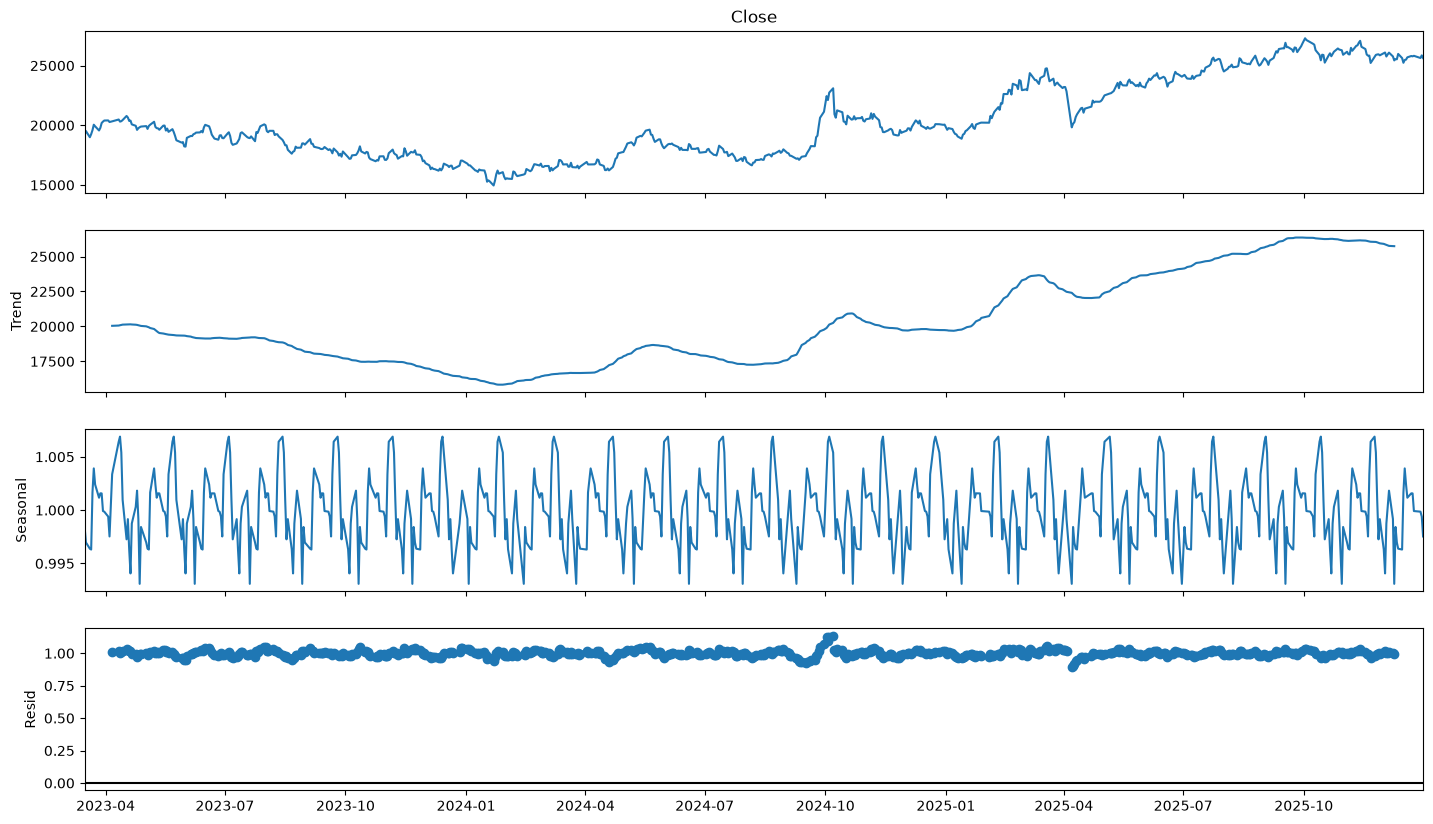

In [24]:
#from statsmodels.tsa.seasonal import seasonal_decompose

#To plot & view the trend and the seasonality
# here set the period to 28 as monthly average 

df_close = df['Close']
result = seasonal_decompose(df_close, model='multiplicative',period=28)
fig = plt.figure()  
fig = result.plot()  
fig.set_size_inches(16, 9)

Text(0.5, 1.0, 'Transformed data')

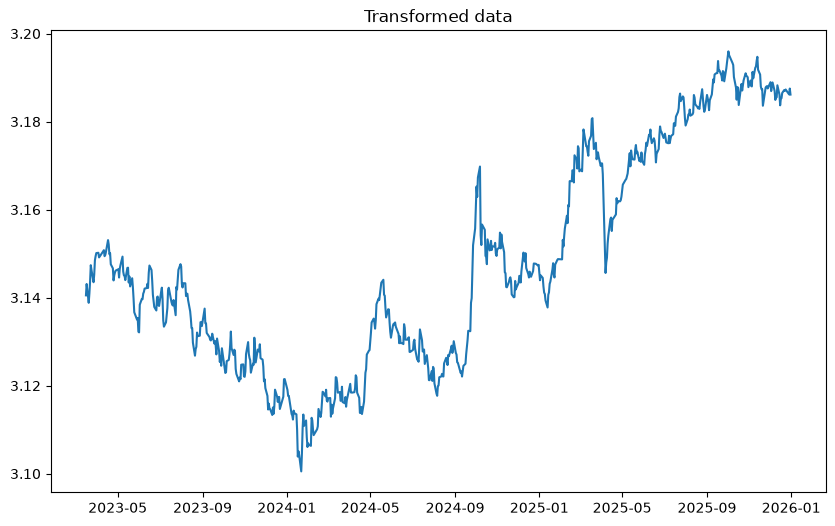

In [25]:
#... To apply log transform to reduce the trends effect while square root transform to flatten 

df_close_log = df_close.apply(np.log)
df_close_tf = df_close_log.apply(np.sqrt)

plt.figure(figsize = (10,6))
plt.plot(df_close_tf)
plt.title('Transformed data')

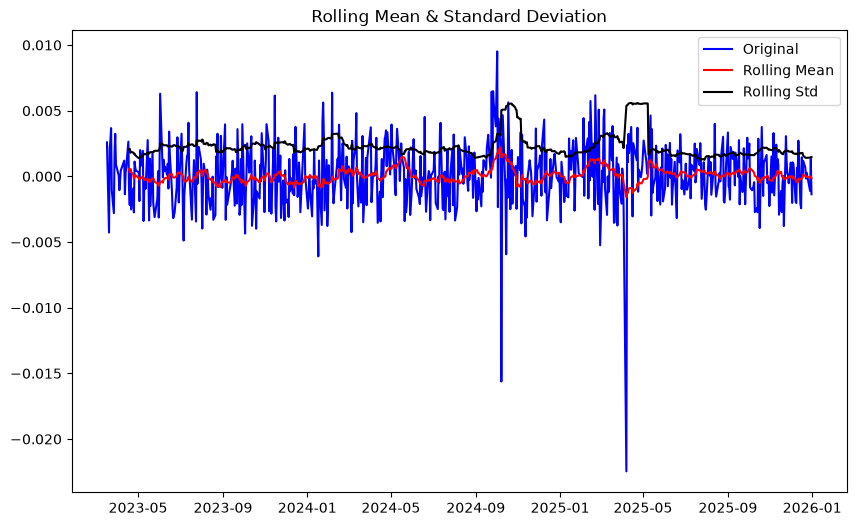

Results of Dickey-Fuller Test:
Test Statistic                 -25.670808
p-value                          0.000000
#Lags Used                       0.000000
Number of Observations Used    684.000000
Critical Value (1%)             -3.439947
Critical Value (5%)             -2.865775
Critical Value (10%)            -2.569025
dtype: float64


In [26]:
#... classical methold differenciating to handel with trand and seasonality
df_close_shift = df_close_tf - df_close_tf.shift()

df_close_shift.dropna(inplace=True)
plt.figure(figsize = (10,6))
test_stationarity(df_close_shift)

check p-value

In [27]:
#...MS LSTM
def preprocess_lstm(sequence, n_steps,n_features):
    X, y = list(), list()
    for i in range(len(sequence)):
        # find the end of this pattern
        end_ix = i + n_steps
        # check if we are beyond the sequence
        if end_ix >= len(sequence):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
        X.append(seq_x)
        y.append(seq_y)
        
    X = np.array(X)
    y = np.array(y)

    X = X.reshape((X.shape[0], X.shape[1], n_features))
    return X, y

# choose the number of days on which to base our predictions 
#nb_days = 60
n_features = 1

X, y = preprocess_lstm(df_close_shift.to_numpy(), nb_days, n_features)

#Split the data set between the training set and the test set (20%)
#test_days = 135 

X_train, y_train = X[:-test_days], y[:-test_days]
X_test, y_test = X[-test_days:], y[-test_days:]

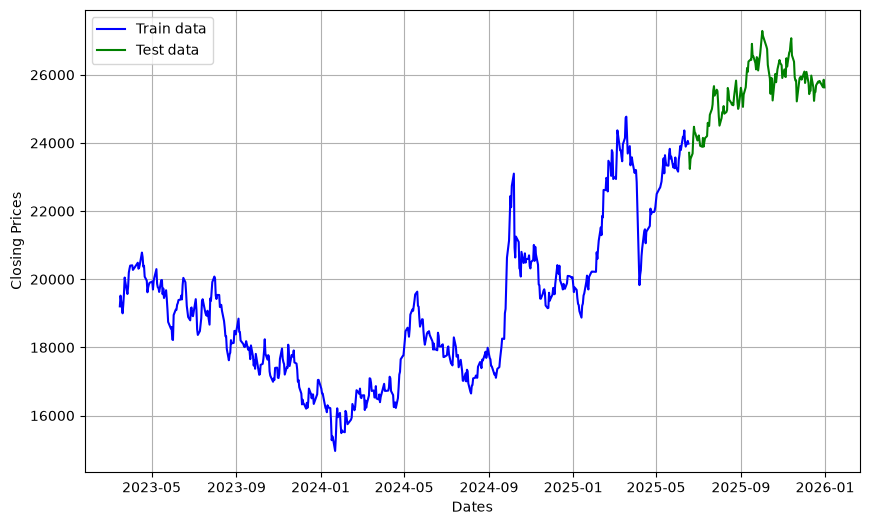

In [28]:
#... Split Data
train_original = df_close.iloc[:-test_days]
test_original = df_close.iloc[-test_days:]

plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(train_original, 'b', label='Train data')
plt.plot(test_original, 'g', label='Test data')
plt.legend()

In [29]:
#... LSTM Vanilla LSTM
def vanilla_LSTM():
    model = Sequential()    
    model.add(LSTM(units=50, input_shape=(nb_days, n_features)))
    model.add(Dense(1))
    return model

#
model = vanilla_LSTM()
model.summary()
model.compile(optimizer='adam', 
              loss='mean_squared_error',
              metrics=[tf.keras.metrics.MeanAbsoluteError()])    

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
#...Train and evaluate model
model.fit(X_train, 
          y_train, 
          epochs=epochsMS, 
          batch_size = batch_sizeMS)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 4.0377e-05 - mean_absolute_error: 0.0051
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 1.9774e-05 - mean_absolute_error: 0.0036
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 9.5820e-06 - mean_absolute_error: 0.0024
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 8.2202e-06 - mean_absolute_error: 0.0021
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 7.3867e-06 - mean_absolute_error: 0.0020
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 7.0881e-06 - mean_absolute_error: 0.0019
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 6.9668e-06 - mean_absolute_error: 0.0019
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 6.8934e-06 - mean_absolute_error: 0.0019
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 6.9595e-06 - mean_absolute_error: 0.0019
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 6.8606e-06 - mean_absolute_error: 0.0019

In [31]:
#...
# Evaluate the model on the test data using
print("Evaluate on test data")
results = model.evaluate(X_test, y_test, batch_size=32)
print("Test MSE:", results[0])
print("Test MAE:", results[1])

Evaluate on test data
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2.8667e-06 - mean_absolute_error: 0.0014
Test MSE: 2.866727982109296e-06
Test MAE: 0.0013902003411203623


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step


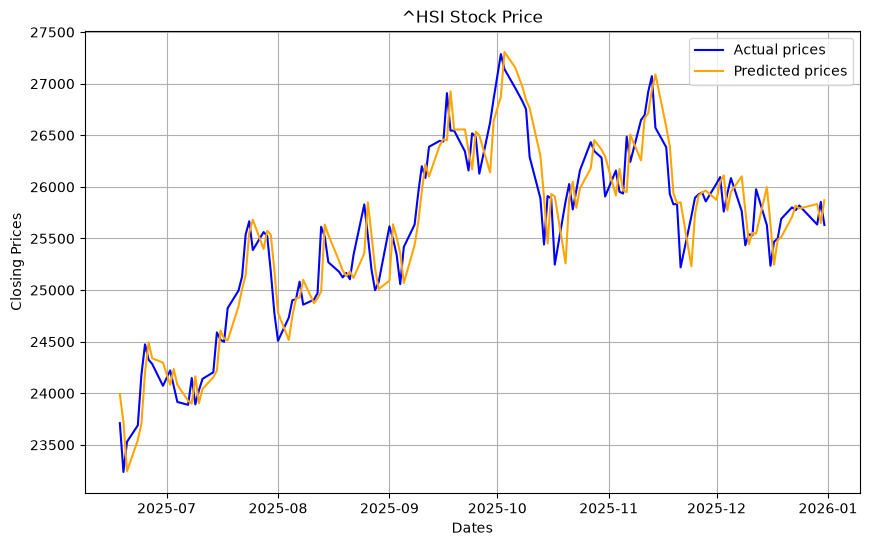

In [32]:
#...
# Prediction
y_pred = model.predict(X_test)

# We create a dataframe from y_pred to have date-time indexes.
pred_data = pd.DataFrame(y_pred[:,0], test_original.index,columns=['Close'])

# Apply inverse transformation from 1.d

# Add the differenciation term
pred_data['Close'] = pred_data['Close'] + df_close_tf.shift().values[-test_days:] 

# Take the square, and the exponent
pred_data = pred_data.apply(np.square)
pred_data = pred_data.apply(np.exp)

# Plot actual prices vs predicted prices 
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(test_original,'b',label='Actual prices')
plt.plot(pred_data, 'orange',label='Predicted prices')
#plt.title(' Stock Price')
plt.title(company + ' Stock Price')

plt.legend()

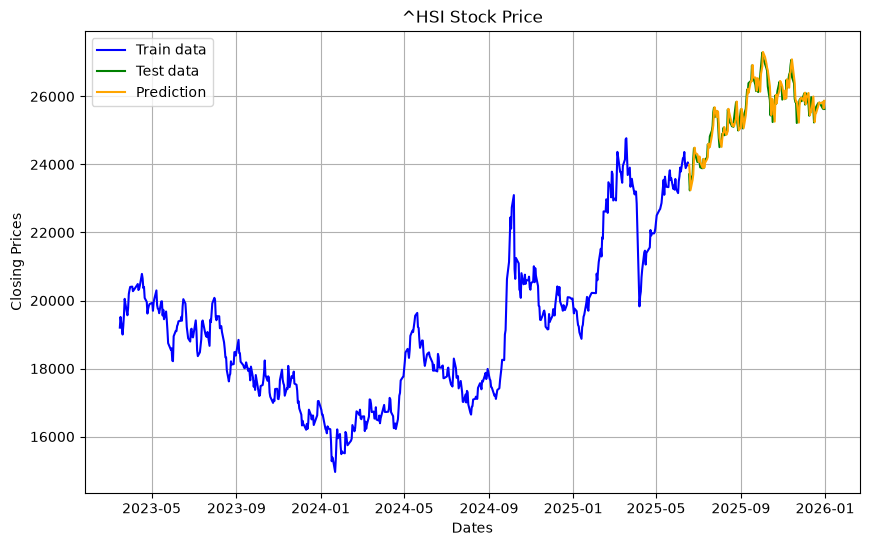

In [33]:
#...
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(train_original, 'b', label='Train data')
plt.plot(test_original, 'g', label='Test data')
plt.plot(pred_data, 'orange', label='Prediction')
plt.title(company + ' Stock Price')
plt.legend()

In [34]:
#...Multiple-Step LSTM
def preprocess_multistep_lstm(sequence, n_steps_in, n_steps_out, features):
    X, y = list(), list()
    for i in range(len(sequence)):
        # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the sequence
        if out_end_ix > len(sequence):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequence[i:end_ix], sequence[end_ix:out_end_ix]
        X.append(seq_x)
        y.append(seq_y)

    X = np.array(X)
    y = np.array(y)

    X = X.reshape((X.shape[0], X.shape[1], n_features))
    
    return X, y

# Number of days into the future we want to predict
#n_steps_out = 30

# choose the number of days on which to base our predictions 
#nb_days = 60

n_features = 1

X, y = preprocess_multistep_lstm(df_close_shift.to_numpy(), nb_days, n_steps_out, n_features)

#
#Split the data set between the training set and the test set (20%)
#test_days = 135 

X_train, y_train = X[:-test_days], y[:-test_days]
X_test, y_test = X[-test_days:], y[-test_days:]

In [35]:
#...
def vanilla_multistep_LSTM():
    model = Sequential()    
    model.add(LSTM(units=50, input_shape=(nb_days, n_features)))
    model.add(Dense(n_steps_out))
    return model

#
model = vanilla_multistep_LSTM()
model.summary()
model.compile(optimizer='adam', 
              loss='mean_squared_error',
              metrics=[tf.keras.metrics.MeanAbsoluteError()])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             510 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,910 (42.62 KB)

 Trainable params: 10,910 (42.62 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
#...
model.fit(X_train, 
          y_train, 
          epochs=epochsMS, 
          batch_size = batch_sizeMS)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - loss: 9.9770e-06 - mean_absolute_error: 0.0024
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 8.0001e-06 - mean_absolute_error: 0.0021
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 7.4085e-06 - mean_absolute_error: 0.0020
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 7.1052e-06 - mean_absolute_error: 0.0019
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 7.1888e-06 - mean_absolute_error: 0.0019
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 7.2484e-06 - mean_absolute_error: 0.0019
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 7.4771e-06 - mean_absolute_error: 0.0020
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - loss: 7.5308e-06 - mean_absolute_error: 0.0020
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 7.3573e-06 - mean_absolute_error: 0.0020
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 7.2649e-06 - mean_absolute_error: 0.0019

In [37]:
#...
# Evaluate the model on the test set
print("Evaluate on test data")
results = model.evaluate(X_test, y_test, batch_size=32)

print("Test MSE:", results[0])
print("Test MAE:", results[1])

Evaluate on test data
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 3.0780e-06 - mean_absolute_error: 0.0014 
Test MSE: 3.077953124375199e-06
Test MAE: 0.0014338144101202488


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step


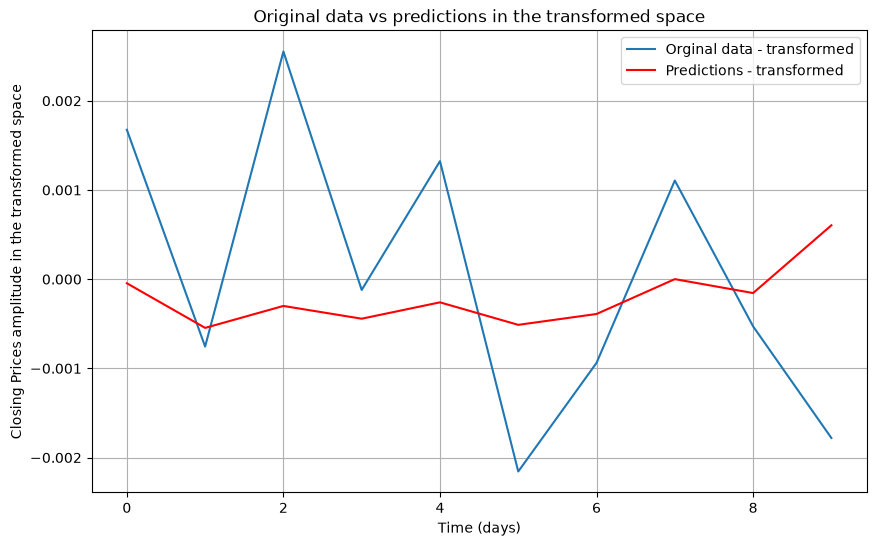

In [38]:
#...
# Prediction
y_pred = model.predict(X_test)

# the_day is the day from which we will study the n_steps_out-th dayS of prediction into 
# the future. Note: The first day start at index 0
the_day = 0
y_pred_days = y_pred[the_day,:]

plt.figure(figsize=(10,6))
plt.grid(True)
plt.plot(y_test[the_day,:],label='Orginal data - transformed')
plt.plot(y_pred_days, color='red',label='Predictions - transformed')
plt.xlabel('Time (days)')
plt.ylabel('Closing Prices amplitude in the transformed space')
plt.title('Original data vs predictions in the transformed space')
plt.legend()

In [39]:
#...
# Apply inverse transformations from 3.a

# Add the differenciation term
pred_diff_cumsum = y_pred_days.cumsum()

base_number = df_close_tf.values[-test_days+the_day+nb_days-1]
idx = test_original.iloc[the_day:the_day+n_steps_out].index

pred_tf = pd.Series(base_number, index=idx)
pred_tf = pred_tf.add(pred_diff_cumsum,fill_value=0)

print(pred_tf)

Date
2025-06-18    3.189551
2025-06-19    3.189005
2025-06-20    3.188705
2025-06-23    3.188262
2025-06-24    3.188002
2025-06-25    3.187490
2025-06-26    3.187100
2025-06-27    3.187100
2025-06-30    3.186945
2025-07-02    3.187549
dtype: float64


In [40]:
#...
# Take the square, and the exponent
pred_log = pred_tf.apply(np.square)
pred = pred_log.apply(np.exp)
print(pred)

Date
2025-06-18    26192.656913
2025-06-19    26101.581521
2025-06-20    26051.670998
2025-06-23    25978.158883
2025-06-24    25935.188566
2025-06-25    25850.674272
2025-06-26    25786.443064
2025-06-27    25786.535448
2025-06-30    25760.983936
2025-07-02    25860.360473
dtype: float64


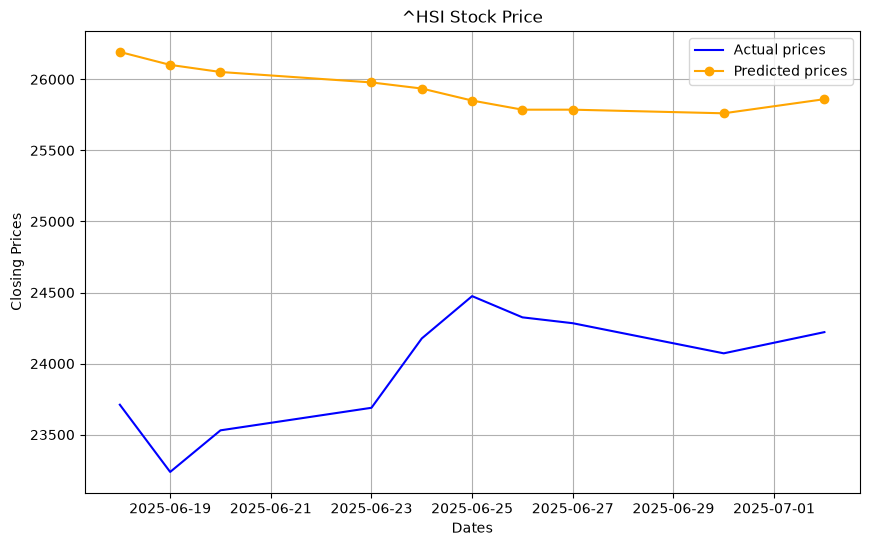

In [41]:
#...
# Plot actual prices vs predicted prices 
plt.figure(figsize=(10,6))
plt.grid(True)
plt.xlabel('Dates')
plt.ylabel('Closing Prices')
plt.plot(test_original.iloc[max(0,the_day-30):the_day+n_steps_out],'b',label='Actual prices')
plt.plot(pred, '-o',color='orange',label='Predicted prices')
plt.title(company + ' Stock Price')

plt.legend()

In [45]:
#import pandas as pd
#import numpy as np
#import matplotlib.pyplot as plt
#import seaborn as sns
from sklearn.metrics import r2_score
import statsmodels.api as sm

#
actual_for_pred_period = test_original.iloc[the_day : the_day + n_steps_out]

#
y_true = actual_for_pred_period.values.flatten()
y_pred = pred.flatten() if hasattr(pred, 'flatten') else pred

X = sm.add_constant(y_true)

#fit linear regression model
model = sm.OLS(y_pred, X).fit()

#view model summary
summary = model.summary()
print(summary)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.641
Model:                            OLS   Adj. R-squared:                  0.596
Method:                 Least Squares   F-statistic:                     14.30
Date:                Fri, 02 Oct 2026   Prob (F-statistic):            0.00538
Time:                        22:29:47   Log-Likelihood:                -58.492
No. Observations:                  10   AIC:                             121.0
Df Residuals:                       8   BIC:                             121.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.294e+04   1855.045     17.759      0.0

In [46]:
#import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculate Metrics
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)  # Alternative: mean_squared_error(y_true, y_pred, squared=False)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

# Calculate Directional Accuracy (Crucial for price trends)
actual_direction = np.diff(y_true) > 0
predicted_direction = np.diff(y_pred) > 0
directional_accuracy = np.mean(actual_direction == predicted_direction) * 100

#
print("--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE):      {mae:.4f}")
print(f"Mean Squared Error (MSE):       {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Pct Error (MAPE): {mape:.2f}%")
print(f"Directional Accuracy (DA):      {directional_accuracy:.2f}%")


--- Model Evaluation Metrics ---
Mean Absolute Error (MAE):      1958.1233
Mean Squared Error (MSE):       4087185.6189
Root Mean Squared Error (RMSE): 2021.6789
Mean Absolute Pct Error (MAPE): 8.20%
Directional Accuracy (DA):      44.44%


In [234]:
# Follow from ADF Test if series is stationary
scaler = MinMaxScaler()
df['Close'] = scaler.fit_transform(df[['Close']])

In [236]:
# Train and Verify Split (80:20 Ratio)
#from sklearn.model_selection import train_test_split

def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back):
        dataX.append(dataset[i:(i + look_back)])
        dataY.append(dataset[i + look_back])
    return np.array(dataX), np.array(dataY)

close_values = df['Close'].values 

X, Y = create_dataset(close_values, look_back=30)

trainX, testX, trainY, testY = train_test_split(X, Y, test_size=0.2, shuffle=False)


In [237]:
# Data for LSTM 
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1], 1))
testX = np.reshape(testX, (testX.shape[0], testX.shape[1], 1))

In [229]:
#1 LSTM ***SKIP
model = Sequential()
model.add(LSTM(units=50, input_shape=(30, 1)))
model.add(Dense(units=1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.summary()
model.fit(trainX, trainY, epochs=epochs2, batch_size=batch_size2)

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                       │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 0.0593
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0085
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0052
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0041
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0037
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0036
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0034
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0033
Epoch 9/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0032
Epoch 10/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0031
Epoch 11/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0029
Epoch 12/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0028
Epoch 13/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0028
Epoch 14/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0027
Epoch 15/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0026
Epoc

#
LSTM(50 units) → Captures long-term dependencies

Dropout(0.2) → Prevents overfitting

Dense Layers → Produces final prediction

In [238]:
#2 LSTM
#from tensorflow.keras.models import Sequential  
#from tensorflow.keras.layers import LSTM, Dense, Dropout  

model = Sequential([  
    LSTM(units=50, return_sequences=True, input_shape=(trainX.shape[1], 1)),  
    Dropout(0.2),  
    LSTM(units=50, return_sequences=False),  
    Dropout(0.2),  
    Dense(units=25),  
    Dense(units=1)  
])  

model.compile(optimizer='adam', loss='mean_squared_error')

model.fit(trainX, trainY, epochs=epochs2, batch_size=batch_size2)

Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - loss: 0.0350
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0106
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0056
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0048
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0050
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0041
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0043
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0041
Epoch 9/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0041
Epoch 10/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0036
Epoch 11/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0039
Epoch 12/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0034
Epoch 13/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0035
Epoch 14/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0030
Epoch 15/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0032
Epoc

In [239]:
# Prediction & Result
testPredict = model.predict(testX)
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform(testY.reshape(-1, 1))

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step


In [240]:
#from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(testY, testPredict))
print(f"Root Mean Squared Error (RMSE): {rmse}")

Root Mean Squared Error (RMSE): 0.05431627160853744


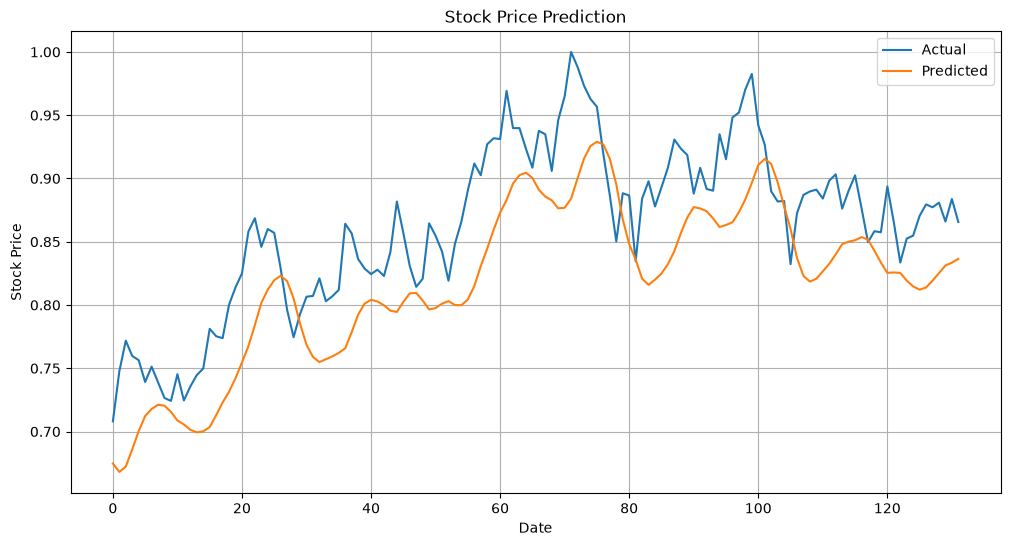

In [241]:
#2
plt.figure(figsize=(12, 6))
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.title("Stock Price Prediction")
plt.plot(testY, label='Actual')
plt.plot(testPredict, label='Predicted')
plt.grid(True)
plt.legend()
plt.show()

For this study, we will focus on the closing price, as it represents the final market sentiment for each trading day.